# TEM Tango Control — Client Tutorial - DB mode
Run the Tango stack before starting the client notebook.

---

## 1. Start Tango Database

```bash
TANGO_HOST=localhost:11000 uv run python -m tango.databaseds.database 2
````

Expected output:

```
Ready to accept request
```

---

## 2. Register Devices

```bash
export TANGO_HOST=localhost:11000
uv run scripts/2_register_devices.py
```

Expected output:

```
registered: test/haadf/1
registered: test/microscope/1
property: haadf_device_address = test/haadf/1
Done!
```

---

## 3. Start Servers

```bash
export TANGO_HOST=localhost:11000
uv run python -m asyncroscopy.detectors.HAADF haadf_instance
uv run python -m asyncroscopy.hardware.STAGE stage_instance
```

---

## 4. Start Microscope

```bash
export TANGO_HOST=localhost:11000
uv run python -m asyncroscopy.ThermoMicroscope microscope_instance
```

Expected:

```
Ready to accept request
```

---
If You Get “Address Already in Use” It means something is already running on that port (likely from a previous session).

Quick one-liner:
```bash
kill -9 $(lsof -t -i:11000)
```

In [1]:
import os
import json
import tango
import numpy as np
import matplotlib.pyplot as plt

## 1. Connect to devices

In [2]:
# Tango DB running on this
os.environ["TANGO_HOST"] = "localhost:11000"
# os.environ["TANGO_HOST"] = "10.46.217.241:9094"


# list devices on DB
db = tango.Database()
devices = db.get_device_name("*", "*")
print("Devices registered in Tango DB:\n")
for d in devices:
    print(d)

Devices registered in Tango DB:

asyncroscopy/detector/haadf
asyncroscopy/microscope/thermo
dserver/DataBaseds/2
dserver/DetectorServer/detectors
dserver/EDS/eds_instance
dserver/HAADF/haadf_instance
dserver/MicroscopeServer/microscope
dserver/STAGE/eds_instance
dserver/STAGE/stage_instance
dserver/TangoAccessControl/1
dserver/TangoTest/test
dserver/ThermoMicroscope/microscope_instance
sys/access_control/1
sys/database/2
sys/tg_test/1
test/eds/1
test/haadf/1
test/microscope/1
test/STAGE/1


In [3]:
# --nodb mode — use full tango:// URL with port and #dbase=no suffix
haadf_proxy = tango.DeviceProxy("test/haadf/1")
microscope_proxy = tango.DeviceProxy("test/microscope/1")

haadf_proxy.set_timeout_millis(120_000)
microscope_proxy.set_timeout_millis(120_000)

In [4]:
print('HAADF state     :', haadf_proxy.state())
print('Microscope state:', microscope_proxy.state())


HAADF state     : ON
Microscope state: ON


In [5]:
haadf_proxy.dwell_time   = 5e-6   # µs
haadf_proxy.image_width  = 256
haadf_proxy.image_height = 256

print('dwell_time  :', haadf_proxy.dwell_time)
print('image_width :', haadf_proxy.image_width)
print('image_height:', haadf_proxy.image_height)

dwell_time  : 5e-06
image_width : 256
image_height: 256


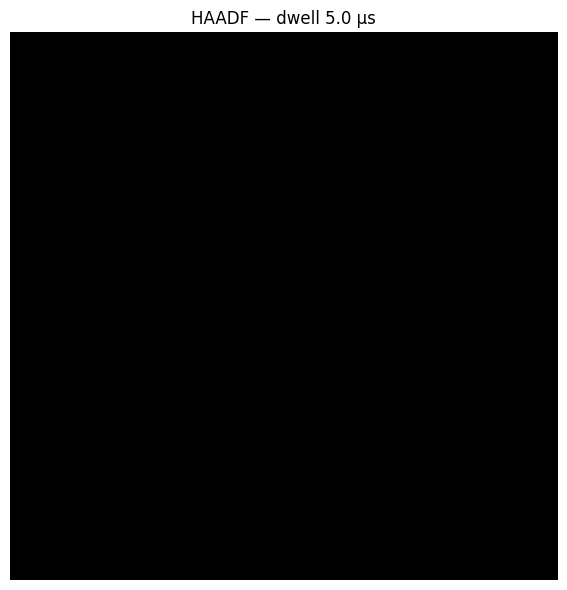

In [23]:
# get_image returns DevEncoded = (json_metadata_str, raw_bytes)
# json_meta, raw_bytes = microscope_proxy.get_image('haadf')

metadata  = dict(json.loads(json_meta))
image = np.frombuffer(raw_bytes, dtype=metadata['dtype']).reshape(metadata['shape'])

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image, cmap='gray', interpolation='none')
ax.set_title(f"HAADF — dwell {metadata['dwell_time']*1e6:.1f} µs")
ax.axis('off')
plt.tight_layout()
plt.show()

In [73]:
# get the stage
starting_position = microscope_proxy.get_stage()
print('Stage position:', starting_position)


Stage position: [ 1.0009413e-04 -1.4997712e-04 -9.5936630e-05 -3.1360000e-06]


In [74]:
starting_position

array([ 1.0009413e-04, -1.4997712e-04, -9.5936630e-05, -3.1360000e-06],
      dtype=float32)

In [85]:
# move the stage
move_by = -100e-6  # 10 µm

new_position = starting_position + np.array([move_by, 0, 0, 1])

In [86]:
microscope_proxy.move_stage(new_position)

In [87]:
microscope_proxy.move_stage(starting_position)